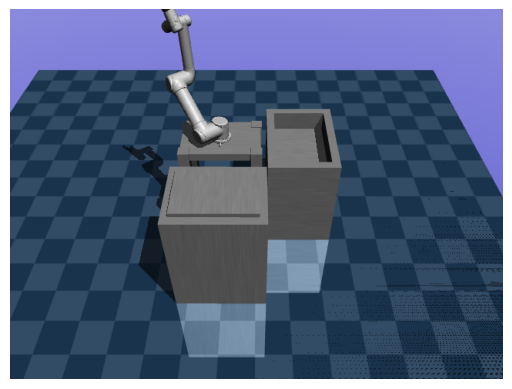

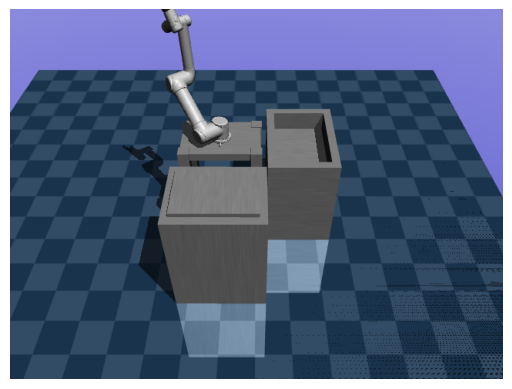

array([[[138, 138, 221],
        [138, 138, 221],
        [138, 138, 221],
        ...,
        [138, 138, 221],
        [138, 138, 221],
        [138, 138, 221]],

       [[138, 138, 221],
        [138, 138, 221],
        [138, 138, 221],
        ...,
        [138, 138, 221],
        [138, 138, 221],
        [138, 138, 221]],

       [[137, 137, 221],
        [137, 137, 221],
        [137, 137, 221],
        ...,
        [137, 137, 221],
        [137, 137, 221],
        [137, 137, 221]],

       ...,

       [[ 25,  51,  76],
        [ 25,  51,  76],
        [ 25,  51,  76],
        ...,
        [ 51,  76, 102],
        [ 51,  76, 102],
        [ 51,  76, 102]],

       [[ 25,  51,  76],
        [ 25,  51,  76],
        [ 25,  51,  76],
        ...,
        [ 51,  76, 102],
        [ 51,  76, 102],
        [ 51,  76, 102]],

       [[ 25,  51,  76],
        [ 25,  51,  76],
        [ 25,  51,  76],
        ...,
        [ 20,  29,  39],
        [ 20,  29,  39],
        [ 20,  29,  39]]

In [49]:
from pathlib import Path
import numpy as np
import mujoco
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPDController import RobotPDController
import matplotlib.pyplot as plt

MODEL_PATH = Path.cwd().parent / "models" / "UR5gripper_2_finger_KKI.xml"
MujModel = RobotMujocoModel(MODEL_PATH)
WarmStartController = RobotPDController(MujModel)
MujModel.reset()  # reset to initial state (q0, v0)
x0 = MujModel.current_state()

rng = np.random.default_rng(0)
q0 = x0[:MujModel.q_indices().size]
q_target = q0 + rng.uniform(-0.4, 0.4, size=q0.shape)
v_target = np.zeros_like(MujModel.v_indices(), dtype=float)
x_target = np.concatenate([q_target, v_target])
warm_xs, warm_us = WarmStartController.compute_control(x0, x_target, 3000)
MujModel.data.qpos[MujModel.q_indices()] = x_target[:MujModel.q_indices().size]
mujoco.mj_forward(MujModel.model, MujModel.data)
MujModel.snapshot(plot=True)
MujModel.data.qpos[MujModel.q_indices()] = warm_xs[-1][:MujModel.q_indices().size]
mujoco.mj_forward(MujModel.model, MujModel.data)
MujModel.snapshot(plot=True)


3001


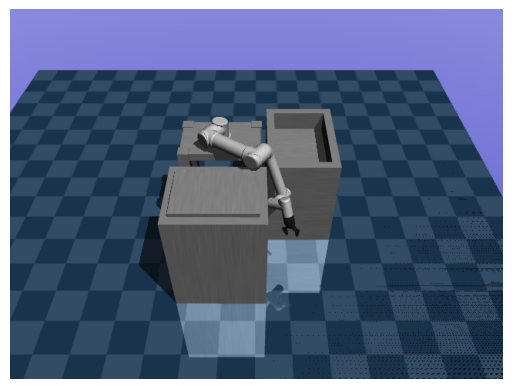

array([[[138, 138, 221],
        [138, 138, 221],
        [138, 138, 221],
        ...,
        [138, 138, 221],
        [138, 138, 221],
        [138, 138, 221]],

       [[138, 138, 221],
        [138, 138, 221],
        [138, 138, 221],
        ...,
        [138, 138, 221],
        [138, 138, 221],
        [138, 138, 221]],

       [[137, 137, 221],
        [137, 137, 221],
        [137, 137, 221],
        ...,
        [137, 137, 221],
        [137, 137, 221],
        [137, 137, 221]],

       ...,

       [[ 25,  51,  76],
        [ 25,  51,  76],
        [ 25,  51,  76],
        ...,
        [ 51,  76, 102],
        [ 51,  76, 102],
        [ 51,  76, 102]],

       [[ 25,  51,  76],
        [ 25,  51,  76],
        [ 25,  51,  76],
        ...,
        [ 51,  76, 102],
        [ 51,  76, 102],
        [ 51,  76, 102]],

       [[ 25,  51,  76],
        [ 25,  51,  76],
        [ 25,  51,  76],
        ...,
        [ 20,  29,  39],
        [ 20,  29,  39],
        [ 20,  29,  39]]

In [30]:
from optimal.RobotCrocoddylController import RobotCrocoddylController

CrocoddylController = RobotCrocoddylController(MujModel, x_target)
crocoddyl_xs, crocoddyl_us = CrocoddylController.get_control(warm_xs, warm_us, x0, solver='FDDP')

import time
import mujoco
import mujoco.viewer

MujModel.reset()  # reset to initial state (q0, v0)

print(len(crocoddyl_xs))

with mujoco.viewer.launch_passive(MujModel.model, MujModel.data) as viewer:
    for _ in range(len(crocoddyl_us)):
        u_cmd = crocoddyl_us[_]
        MujModel.data.ctrl[:] = u_cmd
        mujoco.mj_step(MujModel.model, MujModel.data)
        viewer.sync()
        time.sleep(MujModel.model.opt.timestep)
x_end = MujModel.current_state()
q_err = np.linalg.norm(x_end[:MujModel.q_indices().size] - x_target[:MujModel.q_indices().size])
print(f'Open-loop final q error: {q_err:.4f}')
MujModel.snapshot(plot=True)


In [ ]:
MujModel.reset()  # reset to initial state (q0, v0)
x0 = MujModel.current_state()

HORIZON = 120
CONTROL_DT = 0.02  # optimize at 50 Hz instead of every MuJoCo substep
N_SUBSTEPS = max(1, int(round(CONTROL_DT / MujModel.model.opt.timestep)))
MAX_MPC_STEPS = 1000

WarmStartController = RobotPDController(MujModel)
warm_xs, warm_us = WarmStartController.compute_control(x0, x_target, HORIZON)
CrocoddylController = RobotCrocoddylController(MujModel, x_target, dt=CONTROL_DT)
warm_xs, warm_us = CrocoddylController.get_control(warm_xs, warm_us, x0, solver='FDDP')

MujModel.reset()  # reset to initial state (q0, v0)
with mujoco.viewer.launch_passive(MujModel.model, MujModel.data) as viewer:
    for step in range(MAX_MPC_STEPS):
        if not viewer.is_running():
            break
        x0 = MujModel.current_state()
        q_err = np.linalg.norm(x0[:MujModel.q_indices().size] - x_target[:MujModel.q_indices().size])
        v_err = np.linalg.norm(x0[MujModel.q_indices().size:])
        if q_err < 1e-2 and v_err < 1e-2:
            print(f'Reached target in {step} MPC updates: q_err={q_err:.4f}, v_err={v_err:.4f}')
            break

        warm_xs = list(warm_xs)
        warm_us = list(warm_us)
        warm_xs = warm_xs[1:] + [warm_xs[-1]]
        warm_us = warm_us[1:] + [warm_us[-1]]
        warm_xs[0] = x0.copy()

        crocoddyl_xs, crocoddyl_us = CrocoddylController.get_control(
            warm_xs, warm_us, x0, use_previous_attrs=True
        )
        u0 = np.asarray(crocoddyl_us[0], dtype=float)
        for _ in range(N_SUBSTEPS):
            MujModel.data.ctrl[:] = u0
            mujoco.mj_step(MujModel.model, MujModel.data)
            viewer.sync()
            time.sleep(MujModel.model.opt.timestep)

        warm_xs, warm_us = list(crocoddyl_xs), list(crocoddyl_us)
    else:
        print(f'Max MPC steps reached: q_err={q_err:.4f}, v_err={v_err:.4f}')

